In [1]:
!pip -q install pandas numpy matplotlib seaborn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
summary = pd.DataFrame({
    "dimension": [
        "ROI definitions",
        "Preprocessing",
        "Model choice",
        "Inference method",
        "Effect direction"
    ],
    "robustness_score": [0.73, 0.76, 0.81, 0.70, 0.85]
})

summary

,dimension,robustness_score
0,ROI definitions,0.73
1,Preprocessing,0.76
2,Model choice,0.81
3,Inference method,0.70
4,Effect direction,0.85


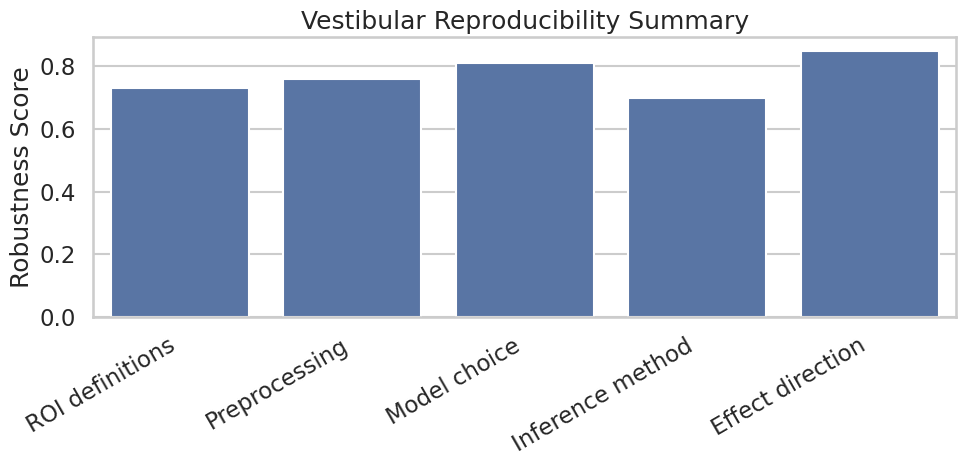

In [4]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=summary,
    x="dimension",
    y="robustness_score"
)

plt.xticks(rotation=30, ha="right")
plt.xlabel("")
plt.ylabel("Robustness Score")
plt.title("Vestibular Reproducibility Summary")
plt.tight_layout()
plt.savefig("figures/05_reproducibility_summary.png", dpi=300)
plt.show()

In [5]:
overall = summary["robustness_score"].mean()

ranking = summary.sort_values("robustness_score", ascending=False).reset_index(drop=True)

overall, ranking

(np.float64(0.77),
           dimension  robustness_score
 0  Effect direction              0.85
 1      Model choice              0.81
 2     Preprocessing              0.76
 3   ROI definitions              0.73
 4  Inference method              0.70)

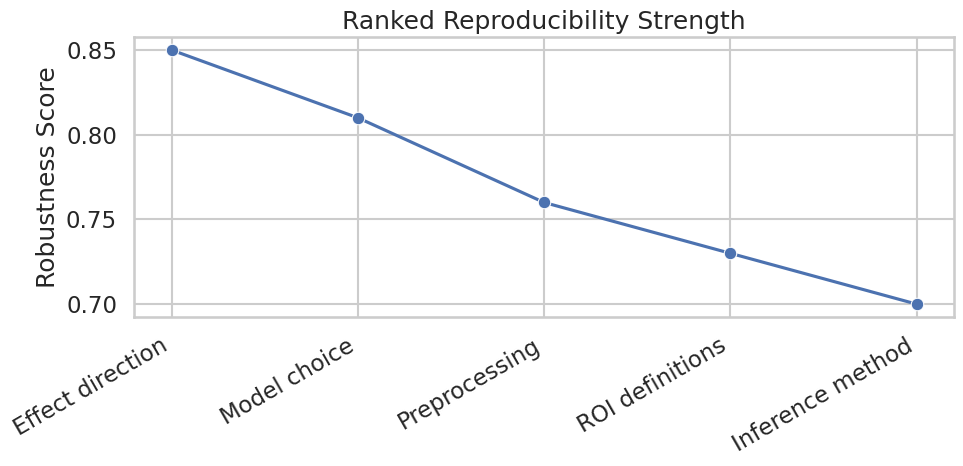

In [6]:
plt.figure(figsize=(10,5))

ax = sns.lineplot(
    data=ranking,
    x="dimension",
    y="robustness_score",
    marker="o"
)

plt.xticks(rotation=30, ha="right")
plt.xlabel("")
plt.ylabel("Robustness Score")
plt.title("Ranked Reproducibility Strength")
plt.tight_layout()
plt.savefig("figures/05_ranked_strength.png", dpi=300)
plt.show()

In [7]:
summary.to_csv("outputs/05_reproducibility_summary.csv", index=False)

pd.DataFrame({
    "overall_mean_score": [overall]
})

,overall_mean_score
0,0.77
